# Compute exposure time

## using SPOCK ETC

In [1]:
import SPOCK.ETC as ETC

# ------- test  ETC

ETC_vec = (ETC.etc(mag_val= 13.11 , mag_band='J', spt='M9',filt='I+z',  airmass=1.3, moonphase=0.5, irtf=0.8, num_tel=1, seeing=1.5, gain=1.1))#airmass=1.1, moonphase=0.5, irtf=0.8, num_tel=1, seeing=2., gain=1.1))
texp = ETC_vec.exp_time_calculator(ADUpeak=50000)[0]

print(texp)


INFO:  Please add password.csv file in: /Users/ed268546/Dropbox/Mac/Documents/codes/SPOCK_v2/SPOCK/credentials/
INFO:  OK Password file exists
INFO: Latest target list already updated.
INFO: Target list already in good format
623.7852245756754


## using mphot

In [ ]:
from SPOCK import path_spock


In [3]:
import mphot

Teff_target = 2566 #K
gaia_id = 2635476908753563008

# files used to generate SR
efficiencyFile2 = path_spock + '/SPOCK/files_ETC/SPIRIT/datafiles/systems/pirtSPC_-60.csv'
filterFile2 = path_spock + '/SPOCK/files_ETC/SPIRIT/datafiles/filters/zYJ.csv'

# name to refer to the generated file
name, system_response = mphot.generate_system_response(
    efficiencyFile2, filterFile2
)

# sky properties
props_sky = {
    "pwv": 2.5,  # PWV [mm]
    "airmass": 1.1,  # airmass
    "seeing": 1.,  # seeing (==FWHM) ["]
}
props_callisto = {
    "name": name,
    "plate_scale": 0.35 * (12 / 13.5),
    "N_dc": 230,
    "N_rn": 80,
    "well_depth": 55000,
    "bias_level": 0,
    "well_fill": 0.7,
    "read_time": 0.1,
    "r0": 0.5,
    "r1": 0.14,
    "ap_rad": 3
}


INFO:mphot.core:`/Users/ed268546/env_SPOCKv2/lib/python3.12/site-packages/mphot/datafiles/system_responses/pirtSPC_-60_zYJ_instrument_system_response.csv` has been generated and saved!


In [4]:
# get the precision and components used to calculate it (generates grid if not already present)
result = mphot.get_precision_gaia(
    props_callisto, props_sky, source_id=gaia_id, Teff=Teff_target
)

mphot.display_results(result)


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


,single frame [ppt],10 minute binned [ppt]
,pirtSPC_-60_zYJ,pirtSPC_-60_zYJ
All,4.12,0.400
Star,1.49,0.145
Scintillation,1.78,0.173
Sky,0.751,0.0729
Dark current,1.36,0.132
Read noise,3.03,0.295


,pirtSPC_-60_zYJ
Teff [K],2.57e+3
distance [pc],12.5
N_star [e/s],8.10e+4
star_flux [e/m2/s],1.12e+5
scn [e_rms],802
pixels in aperture [pix],292
ap_radius [pix],9.64
N_sky [e/pix/s],70.5
sky_radiance [e/m2/arcsec2/s],1.01e+3
seeing [arcsec],1.00


,pirtSPC_-60_zYJ
star [mag],12.0
sky [mag/arcsec2],17.1
vega_flux [e/s],4.94e+9


In [5]:
# extract exposure time
image_precision, binned_precision, components = result

exposure_time = components["t [s]"]
int(exposure_time)

5

In [ ]:
## Andor

In [6]:
Teff_target = 2566 #K
gaia_id = 2635476908753563008

efficiencyFile2 = path_spock + '/../mphot/resources/systems/speculoos_Andor_iKon-L-936_-60.csv' #+ '/SPOCK/files_ETC/SPIRIT/datafiles/systems/andorSPC_-60.csv'
filterFile2 = path_spock + '/../mphot/resources/filters/I+z.csv' #+ '/SPOCK/files_ETC/SPIRIT/datafiles/filters/I+z.csv'

# name to refer to the generated file
name, system_response = mphot.generate_system_response(
    efficiencyFile2, filterFile2
)


INFO:mphot.core:`/Users/ed268546/env_SPOCKv2/lib/python3.12/site-packages/mphot/datafiles/system_responses/speculoos_Andor_iKon-L-936_-60_I+z_instrument_system_response.csv` has been generated and saved!


In [8]:

# sky properties
props_sky = {
    "pwv": 2.5,  # PWV [mm]
    "airmass": 1.1,  # airmass
    "seeing": 1.,  # seeing (==FWHM) ["]
}

# instrument properties
props_telescope = {
    "name": name,  # name to get SR/precision grid from file
    "plate_scale": 0.35,  # pixel plate scale ["]
    "N_dc": 0.2,  # dark current [e/pix/s]
    "N_rn": 6.328,  # read noise [e_rms/pix]
    "well_depth": 64000,  # well depth [e/pix]
    "well_fill": 0.7,  # fractional value to fill central target pixel, assuming gaussian (width function of seeing^)
    "read_time": 10.5,  # read time between images [s]
    "r0": 0.5,  # radius of telescope's primary mirror [m]
    "r1": 0.14,  # radius of telescope's secondary mirror [m]
    # "min_exp" : 0,          # optional, minimum exposure time [s]
    # "max_exp" : 120,        # optional, maximum exposure time [s]
    # "ap_rad" : 3            # optional, aperture radius [FWHM, seeing] for photometry -- 3 default == 7 sigma of Gaussian
}

# get the precision and components used to calculate it (generates grid if not already present)
result = mphot.get_precision_gaia(
    props_telescope, props_sky, source_id=gaia_id, Teff=Teff_target,# override_grid=True
)
# extract exposure time
image_precision, binned_precision, components = result
exposure_time = components["t [s]"]

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


In [9]:
exposure_time

np.float64(27.537454995577033)

# Long term scheduler 

In [4]:
import SPOCK.long_term_scheduler as SPOCKLT

#---- Long-term scheduler

schedule = SPOCKLT.Schedules()
schedule.observatory_name = 'Saint-Ex'
schedule.telescope = 'Saint-Ex'
schedule.load_parameters(date_range=['2025-12-01 15:00:00', '2025-12-02 15:00:00'])
schedule.make_schedule(Altitude_constraint=28, Moon_constraint=30)
SPOCKLT.save_schedule(save=True, over_write=True, date_range=schedule.date_range, telescope=schedule.telescope)
SPOCKLT.make_plans(day=schedule.date_range[0], nb_days=schedule.date_range_in_days, telescope=schedule.telescope)


Retrieving planned targets:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:  No plans in your local file for Io on the 2025-12-01, looking online to check which targets are observed
INFO:  No plans in your local file for Europa on the 2025-12-01, looking online to check which targets are observed
INFO:  No plans in your local file for Ganymede on the 2025-12-01, looking online to check which targets are observed
INFO:  No plans in your local file for Callisto on the 2025-12-01, looking online to check which targets are observed
INFO:  No plans in your local file for Artemis on the 2025-12-01, looking online to check which targets are observed
INFO:  No plans in your local file for Saint-Ex on the 2025-12-01, looking online to check which targets are observed


Scheduling :   0%|          | 0/1 [00:00<?, ?it/s]

--------------------------
INFO:  day is :  2025-12-01 15:00:00.000
--------------------------


INFO:mphot.core:`/Users/ed268546/mphot/src/mphot/datafiles/system_responses/speculoos_Andor_iKon-L-936_-60_I+z_instrument_system_response.csv` has been generated and saved!
INFO:mphot.core:`/Users/ed268546/mphot/src/mphot/datafiles/system_responses/speculoos_Andor_iKon-L-936_-60_I+z_instrument_system_response.csv` has been generated and saved!


INFO:  Checking that Sp0632+8305 does not exceed max hours
total_hours 11.84 h texp 225.37172291444003 s
INFO:  Checking that Sp0520+7626 does not exceed max hours
total_hours 0.0 h texp 113.67415402193888 s
INFO:  Checking that Sp0515+6424 does not exceed max hours


INFO:mphot.core:`/Users/ed268546/mphot/src/mphot/datafiles/system_responses/speculoos_Andor_iKon-L-936_-60_I+z_instrument_system_response.csv` has been generated and saved!


total_hours second target of the night 0.0 h texp 124.35942507733904 s


TypeError: 'NoneType' object is not subscriptable

In [ ]:
SPOCKLT.upload_plans(day=schedule.date_range[0], nb_days=schedule.date_range_in_days, telescope=schedule.telescope)


# Short term scheduler

In [ ]:
import SPOCK.short_term_scheduler as SPOCKST
from astropy.time import Time

# ---- Short-term scheduler
schedule = SPOCKST.Schedules()
schedule.load_parameters()
schedule.day_of_night = Time('2025-11-28 15:00:00')
schedule.start_end_range = Time(['2025-11-28 19:04:00', '2025-11-28 20:51:00'])
schedule.observatory_name = 'SNO'
schedule.telescope = 'Artemis'
#schedule.special_target(input_name="Trappist-1")
schedule.special_target_with_start_end(input_name="TIC1883504789")
schedule.make_scheduled_table()
schedule.planification()
schedule.make_night_block()
# SPOCKST.save_schedule(save=True, over_write=True, day=schedule.day_of_night,
#                               telescope=schedule.telescope)
# SPOCKST.make_plans(day=schedule.day_of_night, nb_days=1,
#                           telescope=schedule.telescope)
# SPOCKST.upload_plans(day=schedule.day_of_night, nb_days=1,
#                             telescope = schedule.telescope)


SystemExit: [31mERROR: [30m Observation impossible because the target is not above the altitude constraint at some point during the given time range. 

# Spot coverage WG6 target 

In [1]:
import pandas as pd
import SPOCK.plots_scheduler as SPOCKplot
from SPOCK import user_portal, pwd_portal, user_chart_studio, pwd_chart_studio, \
    path_spock, target_list_from_stargate_path
import SPOCK.short_term_scheduler as SPOCKST
import numpy as np
import matplotlib.pyplot as plt

INFO:  Please add password.csv file in: /Users/ed268546/Dropbox/Mac/Documents/codes/SPOCK_v2/SPOCK/credentials/
INFO:  OK Password file exists
INFO: Latest target list already updated.
INFO: Target list already in good format


In [2]:
# nightshift 
import numpy as np


# Much faster than the previous one
def nightshift__coverage(times, period):
    if period == 0:
        return 1
    else:
        ph = (times + 0.5 * period) % period - (0.5 * period)
        sph_in = np.sort(ph)
        sph_out = sph_in[::-1]

        sph_in_diff = np.abs(np.diff(sph_in))
        sph_out_diff = np.abs(np.diff(sph_out))

        df = np.min(np.diff(times))

        spaces_in = np.sort(
            sph_in[np.hstack([*np.argwhere(sph_in_diff > 4 * df).T, len(sph_in) - 1])]
        )
        spaces_out = np.sort(
            sph_out[np.hstack([*np.argwhere(sph_out_diff > 4 * df).T, len(sph_in) - 1])]
        )

        return np.sum(spaces_in - spaces_out) / period


vectorize_coverage = np.vectorize(nightshift__coverage, signature="(n),()->()")


def nightshift_coverage(times: list, periods: np.array):
    """Returns the phase coverage for given period(s)

    Parameters
    ----------
    times : list of arrays
        a list of observed times arrays (such as [[0, 1, 2], [5, 6, 7]])
    periods : np.array
        an array of periods (in the same units as :code:`times`)

    Returns
    -------
    np.array
        coverage of each period
    """

    return vectorize_coverage(times, periods)


def nightshift_phase(time, t0, period):
    time = np.asarray(time)
    phases = (time[..., None] - t0 + 0.5 * period) % period - 0.5 * period
    if np.isscalar(period):
        return phases.T[0]
    else:
        return phases


def nightshift_period_match(t0s, periods, tolerance=0.001):
    """Returns a periodogram with period matching most input times

    Parameters
    ----------
    t0s : array
        list of event observed times
    periods : float or array
        periods to match
    tolerance : float, optional
        timing error, by default 0.001

    Returns
    -------
    tuple(np.array, float)
        - number of event matched per period
        - best period
    """
    match = np.count_nonzero(np.abs(nightshift_phase(t0s, t0s[0], periods)) < tolerance, 0)
    best = periods[np.flatnonzero(match == np.max(match))[-1]]
    return match, best

In [3]:
path_target_list = None
times = None
target = 'TOI-1080.01'
fix_expt = None


if path_target_list is None:
    path_target_list = target_list_from_stargate_path
schedules_st = SPOCKST.Schedules()
schedules_st.load_parameters()
target_list_follow_up = schedules_st.target_table_spc_follow_up
target_list_follow_up = target_list_follow_up.sort_values(by="Sp_ID")
target_list_speculoos = pd.read_csv(path_target_list, sep=',')
target_list_speculoos = target_list_speculoos.sort_values(by="Sp_ID")

all_targets = pd.DataFrame({'Sp_ID': pd.concat([target_list_follow_up['Sp_ID'],
                                                target_list_speculoos["Sp_ID"]]),
                            "Gaia_ID": pd.concat([target_list_follow_up['Gaia_ID'],
                                                    target_list_speculoos["Gaia_ID"]])})
all_targets.reset_index(inplace=True)
idx_target_list = list(all_targets['Sp_ID']).index(target)
if times is None:
    # data = getSPClcV2(target=target, ap='', pwvCorr=0)
    #
    # t = data['BJDMID-2450000']
    # t = t.fillna(0)
    # t = np.sort(t)
    t, diff_flux, exposures, dates, target_name, times = SPOCKplot.get_all_LCS(
        gaia_id_target=all_targets['Gaia_ID'][idx_target_list],
        fix_expt=fix_expt)
else:
    t = times

INFO:  Downloading LC of TOI-1080 16672 on Io the 20211002
INFO:  Downloading LC of TOI-1080.01 16672 on Io the 20211022
INFO:  Downloading LC of TOI-1080 16672 on Io the 20230414
INFO:  Downloading LC of TOI-1080 16672 on Ganymede the 20230626
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230630
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230701
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230702
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230704
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230705
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230706
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230707
INFO:  Downloading LC of TOI-1080 16672 on Europa the 20230711
INFO:  Downloading LC of TOI-1080 16672 on Io the 20230712
INFO:  Downloading LC of TOI-1080 16672 on Ganymede the 20230713
INFO:  Downloading LC of TOI-1080 16672 on Ganymede the 20230714
INFO:  Downloading LC of TOI-1080 16672 on Ganymede the 202307

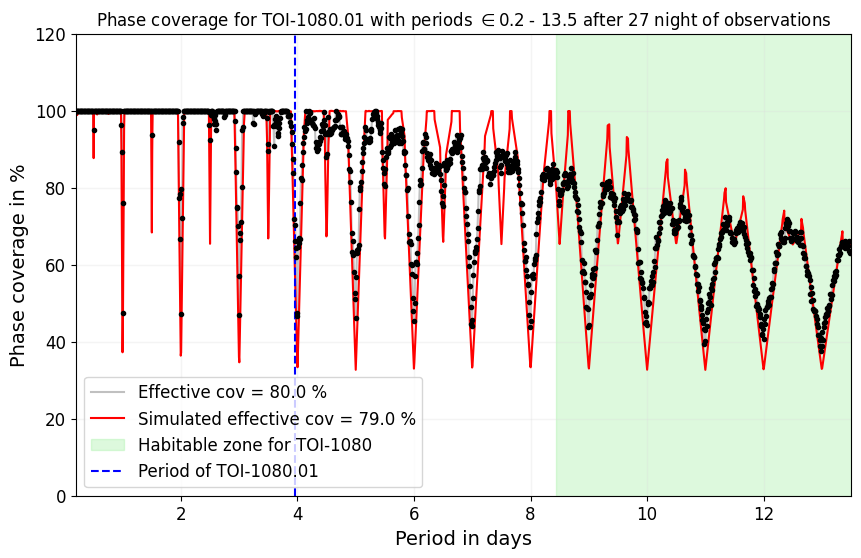

In [46]:
pmin = 0.2
pmax = 13.5
periods = np.arange(pmin, pmax, 0.01)
planetperiod = 3.9652484553964  # days

covs = [SPOCKplot.coverage(t, period) for period in periods]
mean_cov = np.mean(covs) * 100

length = 8/24 # the length (in hours) of a single observation
days = 27 # the number of observations
exposure = 10/60/24 # exposure of an observation

# we observe `length` hours every day for `days` days
times_simu = np.hstack([np.arange(0, length, exposure) + i for i in np.arange(days)])

periods_simu = np.linspace(0.1, pmax, 2000) # in days
covered_simu = nightshift_coverage(times_simu, periods_simu)
mean_covered_simu = np.mean(covered_simu) * 100


fig, ax = plt.subplots(1, figsize=(10, 6))
plt.plot(periods, np.array(covs) * 100, c="silver", label='Effective cov = ' + str(round(mean_cov, 1)) + ' %')
plt.plot(periods, np.array(covs) * 100, ".", c="k", zorder=5)
plt.plot(periods_simu, covered_simu*100, c='r', label='Simulated effective cov = ' + str(round(mean_covered_simu, 1)) + ' %')
ax.fill_betweenx(y=[0, 120], x1=8.4356515423, x2=30.203750392, color='lightgreen', alpha=0.3, label='Habitable zone for TOI-1080')
plt.vlines(planetperiod,0,120, colors='blue', linestyles='dashed', label='Period of TOI-1080.01')

plt.ylim(0, 120)
plt.xlim(pmin, pmax)
plt.ylabel('Phase coverage in %',fontsize=14)
plt.xlabel('Period in days',fontsize=14)
plt.legend(fontsize=12)
ax.tick_params(axis="y", labelsize=12, labelcolor="k")
ax.tick_params(axis='x', labelsize=12,labelcolor='k')
plt.grid(color='gainsboro', linestyle='-', linewidth=1, alpha=0.3)
plt.title(r'Phase coverage for ' + target + r' with periods $\in$' + str(pmin) + ' - ' + str(pmax) + ' after {} night of observations'.format(days))
plt.savefig('phase_coverage_TOI-1080.png', dpi=300)
plt.show()





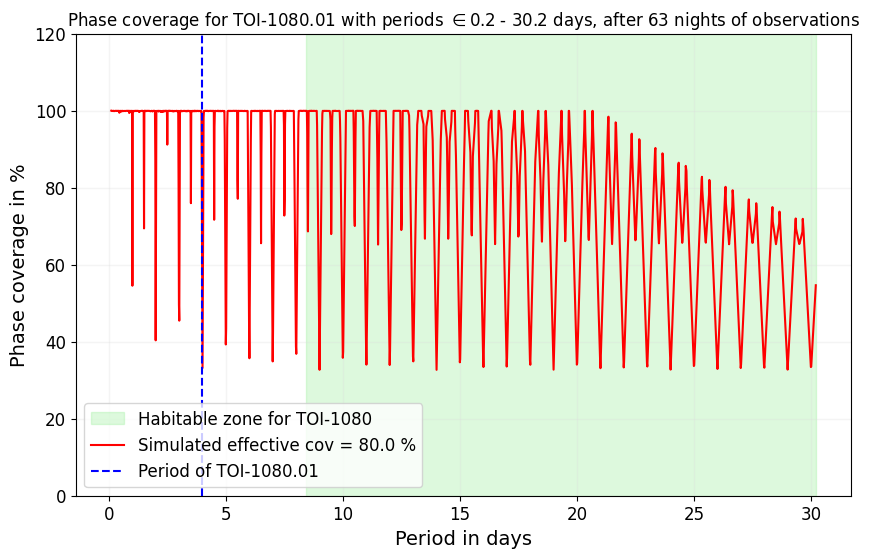

In [43]:
length = 8/24 # the length (in hours) of a single observation
days = 63 # the number of observations
exposure = 10/60/24 # exposure of an observation

# we observe `length` hours every day for `days` days
times_simu = np.hstack([np.arange(0, length, exposure) + i for i in np.arange(days)])

pouterHZ = 30.203750392  # days
periods_simu = np.linspace(0.1, pouterHZ, 2000) # in days
covered_simu = nightshift_coverage(times_simu, periods_simu)
mean_covered_simu = np.mean(covered_simu) * 100

fig, ax = plt.subplots(1, figsize=(10, 6))


ax.fill_betweenx(y=[0, 120], x1=8.4356515423, x2=30.203750392, color='lightgreen', alpha=0.3, label='Habitable zone for TOI-1080')
plt.plot(periods_simu, covered_simu*100, c='r', label='Simulated effective cov = ' + str(round(mean_covered_simu, 1)) + ' %')
plt.vlines(planetperiod,0,120, colors='blue', linestyles='dashed', label='Period of TOI-1080.01')

plt.ylim(0, 120)
plt.ylabel('Phase coverage in %',fontsize=14)
plt.xlabel('Period in days',fontsize=14)
plt.legend(fontsize=12)
ax.tick_params(axis="y", labelsize=12, labelcolor="k")
ax.tick_params(axis='x', labelsize=12,labelcolor='k')
plt.grid(color='gainsboro', linestyle='-', linewidth=1, alpha=0.3)
plt.title(r'Phase coverage for ' + target + r' with periods $\in$' + str(pmin) + ' - ' + str(round(pouterHZ,2)) + ' days, after {} nights of observations'.format(days))
plt.savefig('phase_coverage_TOI-1080_HZ_simu_coverage.png', dpi=300)
plt.show()


# # exposure time vs dates
# if len(dates) > 10:
#     plt.figure(figsize=(int(len(dates) / 4), 4))
# else:
#     plt.figure(figsize=(8, 7))
# plt.plot(dates, exposures, 'H', color='goldenrod', alpha=0.8)
# plt.ylim(min(exposures) - 1, max(exposures) + 1)
# plt.ylabel('Exposure time (seconds)')
# plt.xticks(rotation=60)
# plt.xlabel('Dates', )
# plt.show()




# All TRAPPIST-1 data to look for planet i

In [1]:
import pandas as pd
import SPOCK.plots_scheduler as SPOCKplot
from SPOCK import user_portal, pwd_portal, user_chart_studio, pwd_chart_studio, \
    path_spock, target_list_from_stargate_path
import SPOCK.short_term_scheduler as SPOCKST
import numpy as np
import matplotlib.pyplot as plt

INFO:  Please add password.csv file in: /Users/ed268546/Dropbox/Mac/Documents/codes/SPOCK_v2/SPOCK/credentials/
INFO:  OK Password file exists
INFO: Latest target list already updated.
INFO: Target list already in good format


In [2]:
# nightshift 
import numpy as np


# Much faster than the previous one
def nightshift__coverage(times, period):
    if period == 0:
        return 1
    else:
        ph = (times + 0.5 * period) % period - (0.5 * period)
        sph_in = np.sort(ph)
        sph_out = sph_in[::-1]

        sph_in_diff = np.abs(np.diff(sph_in))
        sph_out_diff = np.abs(np.diff(sph_out))

        df = np.min(np.diff(times))

        spaces_in = np.sort(
            sph_in[np.hstack([*np.argwhere(sph_in_diff > 4 * df).T, len(sph_in) - 1])]
        )
        spaces_out = np.sort(
            sph_out[np.hstack([*np.argwhere(sph_out_diff > 4 * df).T, len(sph_in) - 1])]
        )

        return np.sum(spaces_in - spaces_out) / period


vectorize_coverage = np.vectorize(nightshift__coverage, signature="(n),()->()")


def nightshift_coverage(times: list, periods: np.array):
    """Returns the phase coverage for given period(s)

    Parameters
    ----------
    times : list of arrays
        a list of observed times arrays (such as [[0, 1, 2], [5, 6, 7]])
    periods : np.array
        an array of periods (in the same units as :code:`times`)

    Returns
    -------
    np.array
        coverage of each period
    """

    return vectorize_coverage(times, periods)


def nightshift_phase(time, t0, period):
    time = np.asarray(time)
    phases = (time[..., None] - t0 + 0.5 * period) % period - 0.5 * period
    if np.isscalar(period):
        return phases.T[0]
    else:
        return phases


def nightshift_period_match(t0s, periods, tolerance=0.001):
    """Returns a periodogram with period matching most input times

    Parameters
    ----------
    t0s : array
        list of event observed times
    periods : float or array
        periods to match
    tolerance : float, optional
        timing error, by default 0.001

    Returns
    -------
    tuple(np.array, float)
        - number of event matched per period
        - best period
    """
    match = np.count_nonzero(np.abs(nightshift_phase(t0s, t0s[0], periods)) < tolerance, 0)
    best = periods[np.flatnonzero(match == np.max(match))[-1]]
    return match, best

In [3]:
path_target_list = None
times = None
target = 'Trappist-1b'
fix_expt = None


if path_target_list is None:
    path_target_list = target_list_from_stargate_path
schedules_st = SPOCKST.Schedules()
schedules_st.load_parameters()
target_list_follow_up = schedules_st.target_table_spc_follow_up
target_list_follow_up = target_list_follow_up.sort_values(by="Sp_ID")
target_list_speculoos = pd.read_csv(path_target_list, sep=',')
target_list_speculoos = target_list_speculoos.sort_values(by="Sp_ID")

all_targets = pd.DataFrame({'Sp_ID': pd.concat([target_list_follow_up['Sp_ID'],
                                                target_list_speculoos["Sp_ID"]]),
                            "Gaia_ID": pd.concat([target_list_follow_up['Gaia_ID'],
                                                    target_list_speculoos["Gaia_ID"]])})
all_targets.reset_index(inplace=True)
idx_target_list = list(all_targets['Sp_ID']).index(target)
if times is None:
    # data = getSPClcV2(target=target, ap='', pwvCorr=0)
    #
    # t = data['BJDMID-2450000']
    # t = t.fillna(0)
    # t = np.sort(t)
    t, diff_flux, exposures, dates, target_name, times = SPOCKplot.get_all_LCS(
        gaia_id_target=all_targets['Gaia_ID'][idx_target_list],
        fix_expt=fix_expt)
else:
    t = times

INFO:  Downloading LC of trappist-1 63008 on Europa the 20170612
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170618
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170619
INFO:  Downloading LC of trappist-1 63008 on Io the 20170619
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170629
INFO:  Downloading LC of trappist-1 63008 on Io the 20170629
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170630
INFO:  Downloading LC of trappist-1 63008 on Io the 20170630
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170705
INFO:  Downloading LC of trappist-1 63008 on Io the 20170705
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170708
INFO:  Downloading LC of trappist-1 63008 on Io the 20170708
INFO:  Downloading LC of trappist-1 63008 on Io the 20170709
INFO:  Downloading LC of trappist-1 63008 on Europa the 20170721
INFO:  Downloading LC of trappist-1 63008 on Io the 20170721
INFO:  Downloading LC of trappist-1 63008 on Europa t

In [13]:
df_light_curve = pd.DataFrame({'time': t, 'diff_flux': diff_flux})
df_light_curve = df_light_curve.where(df_light_curve["diff_flux"]>'0.0')

df_light_curve 

,time,diff_flux
0,2.457918e+06,1.0006792962111102
1,2.457918e+06,0.9550267567932245
2,2.457918e+06,1.0079746470828137
3,2.457918e+06,0.9974796197945276
4,2.457918e+06,0.8935389181619916
...,...,...
130054,2.460985e+06,0.9940655392886676
130055,2.460985e+06,1.0003022777189827
130056,2.460985e+06,1.0018150982170109
130057,2.460985e+06,0.998742620036128


In [15]:
df_light_curve["diff_flux"] = [float(str(val)) for val in df_light_curve['diff_flux']]

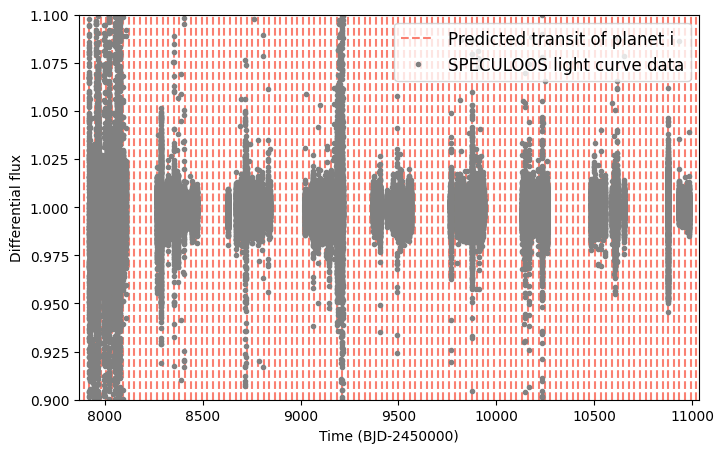

In [54]:
df_timings_i_Eric = pd.read_csv('/Users/ed268546/Dropbox/Mac/Documents/scripts/paper_8th_planet_Eric/T1_tt_forecast_8planet_robust_0.001_eccprior_3_to_2_cycle05.csv', sep=',', header=None)
df_timings_i_Eric.columns = ["planet", "epoch", "t0_predicted", "t0_linear", "TTV", "err_t0_pedicted"]

df = df_timings_i_Eric.where(df_timings_i_Eric["planet"]==8.0).dropna() 
df = df.reset_index()
df.columns = ["index", "planet", "epoch", "t0_predicted", "err_t0_predicted", "t0_linear", "err_t0_linear"]


plt.figure(figsize=(8,5))
plt.vlines(df['t0_predicted'], ymin=0.9, ymax=1.1, colors='salmon', linestyles='dashed', label='Predicted transit of planet i')

plt.plot(df_light_curve['time']-2450000, df_light_curve['diff_flux'], '.', color='gray', label='SPECULOOS light curve data')
plt.xlabel('Time (BJD-2450000)')
plt.ylabel('Differential flux')
plt.ylim(0.9,1.1,)
plt.xlim(min(df_light_curve['time'])-2450000-50, max(df_light_curve['time'])-2450000+50)
plt.legend(fontsize=12)
plt.savefig('light_curve_Trappist-1_with_transit_times_i.png', dpi=300)

In [48]:
import numpy as np

delta_t = 2/24  # days (30 min)

covered_list = []

for t_pred in df['t0_predicted']:
    # Check if any lc datapoints lie within window
    mask = np.abs(df_light_curve["time"]-2450000 - t_pred) < delta_t
    
    if mask.any():
        covered_list.append(t_pred)

print("Predicted transit times with actual data nearby:")
print(covered_list)

Predicted transit times with actual data nearby:
[8782.689076464889, 9098.365907012903]


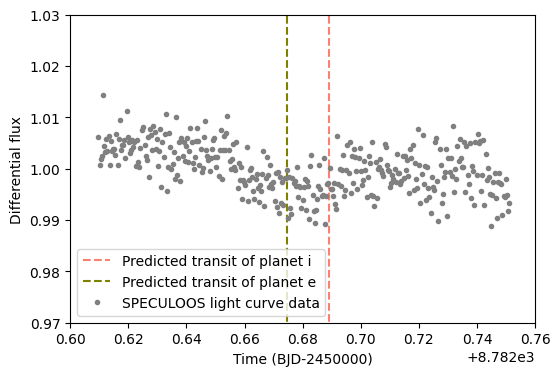

In [57]:
df_timings_i_Eric = pd.read_csv('/Users/ed268546/Dropbox/Mac/Documents/scripts/paper_8th_planet_Eric/T1_tt_forecast_8planet_robust_0.001_eccprior_3_to_2_cycle05.csv', sep=',', header=None)
df_timings_i_Eric.columns = ["planet", "epoch", "t0_predicted", "t0_linear", "TTV", "err_t0_pedicted"]

df = df_timings_i_Eric.where(df_timings_i_Eric["planet"]==8.0).dropna() 
df = df.reset_index()
df.columns = ["index", "planet", "epoch", "t0_predicted", "err_t0_predicted", "t0_linear", "err_t0_linear"]

df_e = df_timings_i_Eric.where(df_timings_i_Eric["planet"]==4.0).dropna() 
df_e = df_e.reset_index()
df_e.columns = ["index", "planet", "epoch", "t0_predicted", "err_t0_predicted", "t0_linear", "err_t0_linear"]


plt.figure(figsize=(6,4))
plt.vlines(df['t0_predicted'], ymin=0.9, ymax=1.1, colors='salmon', linestyles='dashed', label='Predicted transit of planet i')
plt.vlines(df_e['t0_predicted'], ymin=0.9, ymax=1.1, colors='olive', linestyles='dashed', label='Predicted transit of planet e')

plt.plot(df_light_curve['time']-2450000, df_light_curve['diff_flux'], '.', color='gray', label='SPECULOOS light curve data')
plt.xlabel('Time (BJD-2450000)')
plt.ylabel('Differential flux')
plt.ylim(0.97,1.03,)
plt.xlim(8782.6, 8782.76)
plt.legend(fontsize=10,loc=3)
plt.savefig('light_curve_window1_Trappist-1_with_transit_times_i.png', dpi=300)

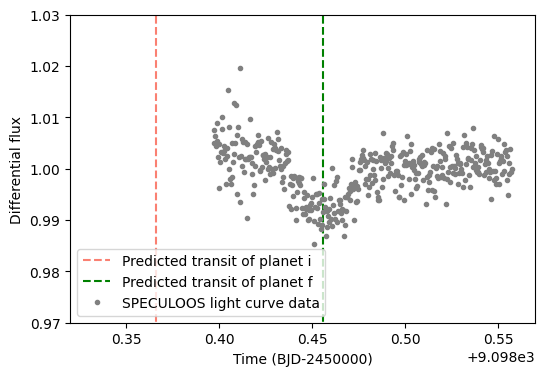

In [56]:
df_timings_i_Eric = pd.read_csv('/Users/ed268546/Dropbox/Mac/Documents/scripts/paper_8th_planet_Eric/T1_tt_forecast_8planet_robust_0.001_eccprior_3_to_2_cycle05.csv', sep=',', header=None)
df_timings_i_Eric.columns = ["planet", "epoch", "t0_predicted", "t0_linear", "TTV", "err_t0_pedicted"]

df = df_timings_i_Eric.where(df_timings_i_Eric["planet"]==8.0).dropna() 
df = df.reset_index()
df.columns = ["index", "planet", "epoch", "t0_predicted", "err_t0_predicted", "t0_linear", "err_t0_linear"]

df_f = df_timings_i_Eric.where(df_timings_i_Eric["planet"]==5.0).dropna() 
df_f = df_f.reset_index()
df_f.columns = ["index", "planet", "epoch", "t0_predicted", "err_t0_predicted", "t0_linear", "err_t0_linear"]


plt.figure(figsize=(6,4))
plt.vlines(df['t0_predicted'], ymin=0.9, ymax=1.1, colors='salmon', linestyles='dashed', label='Predicted transit of planet i')
plt.vlines(df_f['t0_predicted'], ymin=0.9, ymax=1.1, colors='green', linestyles='dashed', label='Predicted transit of planet f')

plt.plot(df_light_curve['time']-2450000, df_light_curve['diff_flux'], '.', color='gray', label='SPECULOOS light curve data')
plt.xlabel('Time (BJD-2450000)')
plt.ylabel('Differential flux')
plt.ylim(0.97,1.03,)
plt.xlim(9098.32, 9098.57)
plt.legend(fontsize=10,loc=3)
plt.savefig('light_curve_window2_Trappist-1_with_transit_times_i.png', dpi=300)